In [68]:
#import librerias ppales para el proyecto
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import jupyter
import streamlit as st
import holidays

In [13]:
# Carga los datos de entrenamiento desde la carpeta data/raw.
df_ventas = pd.read_csv(
    "../data/raw/entrenamiento/ventas.csv",
    parse_dates=["fecha"],
)

df_competencia = pd.read_csv(
    "../data/raw/entrenamiento/competencia.csv",
    parse_dates=["fecha"],
)

print(f"Ventas: {df_ventas.shape[0]:,} filas y {df_ventas.shape[1]} columnas")
print(f"Competencia: {df_competencia.shape[0]:,} filas y {df_competencia.shape[1]} columnas")

Ventas: 3,552 filas y 10 columnas
Competencia: 3,552 filas y 5 columnas


In [14]:
# Asegura que las fechas de ambos DataFrames tengan tipo datetime.
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])
df_competencia["fecha"] = pd.to_datetime(df_competencia["fecha"])

print("Tipo de fecha en df_ventas:", df_ventas["fecha"].dtype)
print("Tipo de fecha en df_competencia:", df_competencia["fecha"].dtype)

Tipo de fecha en df_ventas: datetime64[us]
Tipo de fecha en df_competencia: datetime64[us]


In [23]:
# Integra ventas y competencia con una fila por fecha y producto.
df_ventas_competencia = pd.merge(
    df_ventas,
    df_competencia,
    on=["fecha", "producto_id"],
    how="inner",
    validate="one_to_one",
)

print(
    "Dimensiones del DataFrame integrado:",
    f"{df_ventas_competencia.shape[0]:,} filas x "
    f"{df_ventas_competencia.shape[1]} columnas",
)
df_ventas_competencia.head()

Dimensiones del DataFrame integrado: 3,552 filas x 13 columnas


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


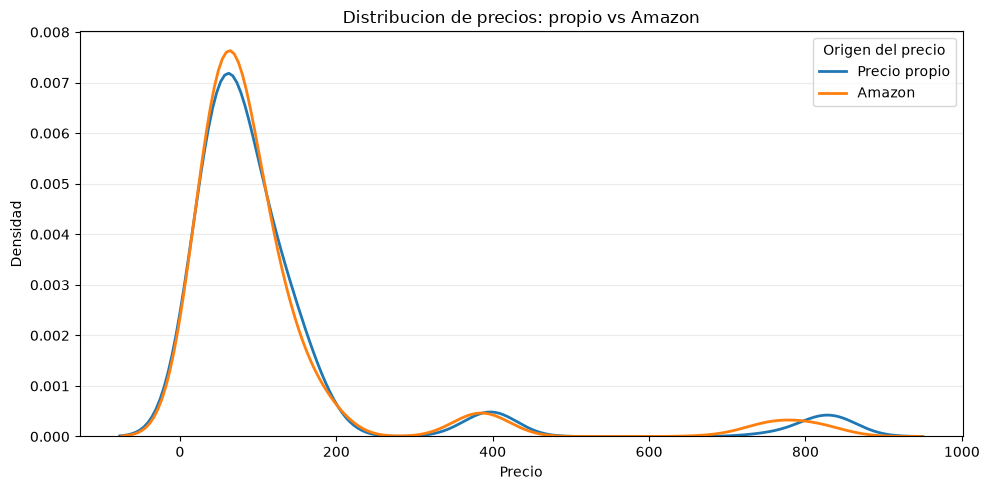

In [24]:
# Compara la distribucion de precios propios y de Amazon.
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=df_ventas_competencia,
    x="precio_venta",
    label="Precio propio",
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    data=df_ventas_competencia,
    x="Amazon",
    label="Amazon",
    linewidth=2,
    ax=ax,
)
ax.set_title("Distribucion de precios: propio vs Amazon")
ax.set_xlabel("Precio")
ax.set_ylabel("Densidad")
ax.legend(title="Origen del precio")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

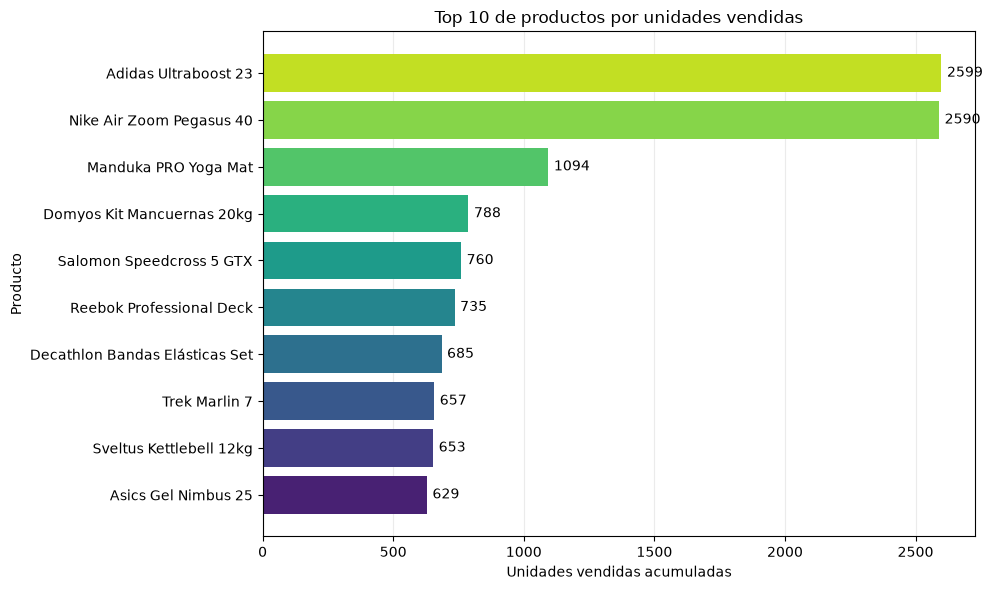

In [25]:
# Suma unidades vendidas por producto y selecciona los diez primeros.
top_10_productos_ventas = (
    df_ventas.groupby(["producto_id", "nombre"], as_index=False)[
        "unidades_vendidas"
    ]
    .sum()
    .nlargest(10, "unidades_vendidas")
    .sort_values("unidades_vendidas")
)

# Grafica el ranking de menor a mayor para dejar el primero arriba.
fig, ax = plt.subplots(figsize=(10, 6))
colores_top_10 = sns.color_palette(
    "viridis",
    n_colors=len(top_10_productos_ventas),
)
barras_top_10 = ax.barh(
    top_10_productos_ventas["nombre"],
    top_10_productos_ventas["unidades_vendidas"],
    color=colores_top_10,
)
ax.bar_label(barras_top_10, padding=4, fmt="%.0f")
ax.set_title("Top 10 de productos por unidades vendidas")
ax.set_xlabel("Unidades vendidas acumuladas")
ax.set_ylabel("Producto")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [15]:
df_ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [16]:
df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [17]:
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='str')

In [18]:
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [19]:
# Informe reproducible de calidad de datos para df_ventas.
filas_ventas, columnas_ventas = df_ventas.shape
nulos_totales = int(df_ventas.isna().sum().sum())
duplicados_exactos = int(df_ventas.duplicated().sum())
duplicados_fecha_producto = int(
    df_ventas.duplicated(subset=["fecha", "producto_id"]).sum()
)

perfil_calidad_ventas = pd.DataFrame(
    {
        "tipo": df_ventas.dtypes.astype(str),
        "valores_nulos": df_ventas.isna().sum(),
        "porcentaje_nulos": (df_ventas.isna().mean() * 100).round(2),
        "valores_unicos": df_ventas.nunique(dropna=False),
    }
)

unidades_no_enteras = int(
    (df_ventas["unidades_vendidas"].dropna() % 1 != 0).sum()
)
unidades_negativas = int((df_ventas["unidades_vendidas"] < 0).sum())
valores_negativos = int(
    (df_ventas[["precio_base", "precio_venta", "ingresos"]] < 0)
    .sum()
    .sum()
)
ingresos_incoherentes = int(
    (
        ~np.isclose(
            df_ventas["ingresos"],
            df_ventas["unidades_vendidas"] * df_ventas["precio_venta"],
            rtol=0,
            atol=0.01,
            equal_nan=True,
        )
    ).sum()
)

controles_calidad_ventas = pd.DataFrame(
    [
        {"control": "Celdas con valores nulos", "incidencias": nulos_totales},
        {"control": "Filas completamente duplicadas", "incidencias": duplicados_exactos},
        {
            "control": "Duplicados por fecha y producto_id",
            "incidencias": duplicados_fecha_producto,
        },
        {"control": "Unidades vendidas negativas", "incidencias": unidades_negativas},
        {"control": "Unidades vendidas no enteras", "incidencias": unidades_no_enteras},
        {
            "control": "Precios o ingresos negativos",
            "incidencias": valores_negativos,
        },
        {
            "control": "Ingresos distintos de unidades * precio_venta",
            "incidencias": ingresos_incoherentes,
        },
    ]
)
controles_calidad_ventas["resultado"] = controles_calidad_ventas[
    "incidencias"
].map(lambda cantidad: "OK" if cantidad == 0 else "REVISAR")

print("INFORME DE CALIDAD DE DATOS: DF_VENTAS")
print(f"Dimensiones: {filas_ventas:,} filas x {columnas_ventas} columnas")
print("\nPERFIL POR COLUMNA")
print(perfil_calidad_ventas.to_string())
print("\nDESCRIPTIVOS NUMERICOS")
print(df_ventas.select_dtypes(include="number").describe().T.to_string())
print("\nDESCRIPTIVOS CATEGORICOS")
print(
    df_ventas[
        ["producto_id", "nombre", "categoria", "subcategoria", "es_estrella"]
    ]
    .describe()
    .T.to_string()
)
print("\nCONTROLES DE CALIDAD")
print(controles_calidad_ventas.to_string(index=False))

if "fecha" in df_ventas.columns and df_ventas["fecha"].notna().any():
    print(
        "\nRango de fechas: "
        f"{df_ventas['fecha'].min().date()} a {df_ventas['fecha'].max().date()}"
    )

incidencias_totales_ventas = int(controles_calidad_ventas["incidencias"].sum())
estado_calidad_ventas = "APROBADA" if incidencias_totales_ventas == 0 else "REQUIERE REVISION"
print(f"\nRESULTADO FINAL: {estado_calidad_ventas}")
print(f"Total de incidencias detectadas: {incidencias_totales_ventas:,}")

INFORME DE CALIDAD DE DATOS: DF_VENTAS
Dimensiones: 3,552 filas x 10 columnas

PERFIL POR COLUMNA
                             tipo  valores_nulos  porcentaje_nulos  valores_unicos
fecha              datetime64[us]              0               0.0             148
producto_id                   str              0               0.0              24
nombre                        str              0               0.0              24
categoria                     str              0               0.0               4
subcategoria                  str              0               0.0              16
precio_base                 int64              0               0.0              21
es_estrella                  bool              0               0.0               2
unidades_vendidas           int64              0               0.0              52
precio_venta              float64              0               0.0            2537
ingresos                  float64              0               0.0      

In [20]:
# Informe reproducible de calidad de datos para df_competencia.
filas_competencia, columnas_competencia = df_competencia.shape
nulos_totales_competencia = int(df_competencia.isna().sum().sum())
duplicados_exactos_competencia = int(df_competencia.duplicated().sum())
duplicados_fecha_producto_competencia = int(
    df_competencia.duplicated(subset=["fecha", "producto_id"]).sum()
)
columnas_precios_competencia = ["Amazon", "Decathlon", "Deporvillage"]
precios_no_positivos_competencia = int(
    (df_competencia[columnas_precios_competencia] <= 0).sum().sum()
)

perfil_calidad_competencia = pd.DataFrame(
    {
        "tipo": df_competencia.dtypes.astype(str),
        "valores_nulos": df_competencia.isna().sum(),
        "porcentaje_nulos": (df_competencia.isna().mean() * 100).round(2),
        "valores_unicos": df_competencia.nunique(dropna=False),
    }
)

claves_ventas = df_ventas[["fecha", "producto_id"]].dropna().drop_duplicates()
claves_competencia = (
    df_competencia[["fecha", "producto_id"]].dropna().drop_duplicates()
)
claves_solo_ventas = int(
    (
        claves_ventas.merge(
            claves_competencia,
            on=["fecha", "producto_id"],
            how="left",
            indicator=True,
        )["_merge"]
        == "left_only"
    ).sum()
)
claves_solo_competencia = int(
    (
        claves_competencia.merge(
            claves_ventas,
            on=["fecha", "producto_id"],
            how="left",
            indicator=True,
        )["_merge"]
        == "left_only"
    ).sum()
)

controles_calidad_competencia = pd.DataFrame(
    [
        {
            "control": "Celdas con valores nulos",
            "incidencias": nulos_totales_competencia,
        },
        {
            "control": "Filas completamente duplicadas",
            "incidencias": duplicados_exactos_competencia,
        },
        {
            "control": "Duplicados por fecha y producto_id",
            "incidencias": duplicados_fecha_producto_competencia,
        },
        {
            "control": "Precios de competencia no positivos",
            "incidencias": precios_no_positivos_competencia,
        },
        {
            "control": "Claves fecha-producto presentes solo en ventas",
            "incidencias": claves_solo_ventas,
        },
        {
            "control": "Claves fecha-producto presentes solo en competencia",
            "incidencias": claves_solo_competencia,
        },
    ]
)
controles_calidad_competencia["resultado"] = controles_calidad_competencia[
    "incidencias"
].map(lambda cantidad: "OK" if cantidad == 0 else "REVISAR")

print("INFORME DE CALIDAD DE DATOS: DF_COMPETENCIA")
print(
    f"Dimensiones: {filas_competencia:,} filas x "
    f"{columnas_competencia} columnas"
)
print("\nPERFIL POR COLUMNA")
print(perfil_calidad_competencia.to_string())
print("\nDESCRIPTIVOS DE PRECIOS POR COMPETIDOR")
print(df_competencia[columnas_precios_competencia].describe().T.to_string())
print("\nCOBERTURA DE CLAVES FRENTE A DF_VENTAS")
print(f"Claves únicas en ventas: {len(claves_ventas):,}")
print(f"Claves únicas en competencia: {len(claves_competencia):,}")
print("\nCONTROLES DE CALIDAD")
print(controles_calidad_competencia.to_string(index=False))

if "fecha" in df_competencia.columns and df_competencia["fecha"].notna().any():
    print(
        "\nRango de fechas: "
        f"{df_competencia['fecha'].min().date()} a "
        f"{df_competencia['fecha'].max().date()}"
    )

incidencias_totales_competencia = int(
    controles_calidad_competencia["incidencias"].sum()
)
estado_calidad_competencia = (
    "APROBADA" if incidencias_totales_competencia == 0 else "REQUIERE REVISION"
)
print(f"\nRESULTADO FINAL: {estado_calidad_competencia}")
print(f"Total de incidencias detectadas: {incidencias_totales_competencia:,}")

INFORME DE CALIDAD DE DATOS: DF_COMPETENCIA
Dimensiones: 3,552 filas x 5 columnas

PERFIL POR COLUMNA
                        tipo  valores_nulos  porcentaje_nulos  valores_unicos
fecha         datetime64[us]              0               0.0             148
producto_id              str              0               0.0              24
Amazon               float64              0               0.0            3125
Decathlon            float64              0               0.0            3001
Deporvillage         float64              0               0.0            3105

DESCRIPTIVOS DE PRECIOS POR COMPETIDOR
               count        mean         std    min      25%     50%       75%       max
Amazon        3552.0  118.623407  156.095628  16.85  47.1175  73.180  114.3425  858.3500
Decathlon     3552.0  111.412182  148.508132  15.45  43.2850  66.285  111.1725  867.3375
Deporvillage  3552.0  118.894628  160.216448  16.77  47.3100  72.700  114.9850  932.3250

COBERTURA DE CLAVES FRENTE A DF_V

In [22]:
df_competencia.info()
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   

In [47]:
# Copia la tabla integrada para conservar intactos los DataFrames originales.
df_modelado = df_ventas_competencia.copy()

# Construye el calendario nacional de festivos para los años presentes en los datos.
anios_con_datos = sorted(
    df_modelado["fecha"].dt.year.dropna().unique().tolist()
)
festivos_espana = holidays.country_holidays("ES", years=anios_con_datos)

# Extrae componentes de calendario y estacionalidad basica.
df_modelado["anio"] = df_modelado["fecha"].dt.year
df_modelado["mes"] = df_modelado["fecha"].dt.month
df_modelado["dia_mes"] = df_modelado["fecha"].dt.day
df_modelado["dia_semana"] = df_modelado["fecha"].dt.dayofweek
df_modelado["dia_del_anio"] = df_modelado["fecha"].dt.dayofyear
df_modelado["semana_anio"] = (
    df_modelado["fecha"].dt.isocalendar().week.astype("int64")
)
df_modelado["trimestre"] = df_modelado["fecha"].dt.quarter
df_modelado["dias_del_mes"] = df_modelado["fecha"].dt.days_in_month

# Crea indicadores de fin de semana, inicio y cierre de mes.
df_modelado["es_fin_de_semana"] = df_modelado["dia_semana"] >= 5
df_modelado["es_inicio_mes"] = df_modelado["dia_mes"] <= 3
df_modelado["es_fin_mes"] = (
    df_modelado["dia_mes"] >= df_modelado["dias_del_mes"] - 2
)

# Anade festivos nacionales espanoles y su nombre cuando corresponda.
df_modelado["nombre_festivo"] = df_modelado["fecha"].dt.date.map(
    festivos_espana
)
df_modelado["es_festivo"] = df_modelado["nombre_festivo"].notna()

# Black Friday es el viernes posterior al cuarto jueves de noviembre.
primer_dia_noviembre = pd.to_datetime(
    df_modelado["anio"].astype(str) + "-11-01"
)
dias_hasta_primer_jueves = (3 - primer_dia_noviembre.dt.dayofweek) % 7
fechas_black_friday_esperadas = (
    primer_dia_noviembre
    + pd.to_timedelta(22 + dias_hasta_primer_jueves, unit="D")
)
fechas_cyber_monday_esperadas = (
    fechas_black_friday_esperadas + pd.Timedelta(days=3)
)
df_modelado["es_black_friday"] = df_modelado["fecha"].eq(
    fechas_black_friday_esperadas
)
df_modelado["es_cyber_monday"] = df_modelado["fecha"].eq(
    fechas_cyber_monday_esperadas
)

# Anade una ventana de campana navidena para capturar estacionalidad comercial.
df_modelado["es_temporada_navidad"] = (
    (df_modelado["mes"].eq(12) & df_modelado["dia_mes"].ge(15))
    | (df_modelado["mes"].eq(1) & df_modelado["dia_mes"].le(6))
)

# Codifica semana y mes de forma ciclica para modelos sensibles a distancias.
df_modelado["dia_semana_sin"] = np.sin(
    2 * np.pi * df_modelado["dia_semana"] / 7
)
df_modelado["dia_semana_cos"] = np.cos(
    2 * np.pi * df_modelado["dia_semana"] / 7
)
df_modelado["mes_sin"] = np.sin(
    2 * np.pi * (df_modelado["mes"] - 1) / 12
)
df_modelado["mes_cos"] = np.cos(
    2 * np.pi * (df_modelado["mes"] - 1) / 12
)

# Resume la cobertura de eventos y muestra las nuevas variables.
print("Variables temporales creadas en df_modelado:")
print(f"Festivos nacionales: {int(df_modelado['es_festivo'].sum()):,} registros")
print(f"Black Friday: {int(df_modelado['es_black_friday'].sum()):,} registros")
print(f"Cyber Monday: {int(df_modelado['es_cyber_monday'].sum()):,} registros")
print(
    "Nota: el calendario usa festivos nacionales; para festivos autonomicos "
    "hay que especificar la comunidad autonoma."
)
df_modelado.head()

Variables temporales creadas en df_modelado:
Festivos nacionales: 96 registros
Black Friday: 96 registros
Cyber Monday: 72 registros
Nota: el calendario usa festivos nacionales; para festivos autonomicos hay que especificar la comunidad autonoma.


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_fin_mes,nombre_festivo,es_festivo,es_black_friday,es_cyber_monday,es_temporada_navidad,dia_semana_sin,dia_semana_cos,mes_sin,mes_cos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,NaN,False,False,False,False,0.0,1.0,-1.0,-1.836970e-16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,NaN,False,False,False,False,0.0,1.0,-1.0,-1.836970e-16
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,NaN,False,False,False,False,0.0,1.0,-1.0,-1.836970e-16
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,NaN,False,False,False,False,0.0,1.0,-1.0,-1.836970e-16
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,NaN,False,False,False,False,0.0,1.0,-1.0,-1.836970e-16


In [48]:
# Compara las fechas de campaña marcadas con las fechas del calendario real.
fechas_disponibles = pd.DatetimeIndex(df_modelado["fecha"].drop_duplicates())
anios_calendario = df_modelado["anio"].drop_duplicates().sort_values()
primer_dia_noviembre = pd.to_datetime(
    anios_calendario.astype(str) + "-11-01"
)
dias_hasta_primer_jueves = (3 - primer_dia_noviembre.dt.dayofweek) % 7
fechas_black_friday_esperadas = (
    primer_dia_noviembre
    + pd.to_timedelta(22 + dias_hasta_primer_jueves, unit="D")
)
fechas_cyber_monday_esperadas = (
    fechas_black_friday_esperadas + pd.Timedelta(days=3)
)
fechas_black_friday_marcadas = pd.DatetimeIndex(
    df_modelado.loc[df_modelado["es_black_friday"], "fecha"].drop_duplicates()
)
fechas_cyber_monday_marcadas = pd.DatetimeIndex(
    df_modelado.loc[df_modelado["es_cyber_monday"], "fecha"].drop_duplicates()
)

print(
    "Black Friday esperado en datos:",
    sorted(fechas_black_friday_esperadas[fechas_black_friday_esperadas.isin(fechas_disponibles)]),
)
print("Black Friday marcado:", sorted(fechas_black_friday_marcadas))
print(
    "Cyber Monday esperado en datos:",
    sorted(fechas_cyber_monday_esperadas[fechas_cyber_monday_esperadas.isin(fechas_disponibles)]),
)
print("Cyber Monday marcado:", sorted(fechas_cyber_monday_marcadas))

Black Friday esperado en datos: [Timestamp('2021-11-26 00:00:00'), Timestamp('2022-11-25 00:00:00'), Timestamp('2023-11-24 00:00:00'), Timestamp('2024-11-29 00:00:00')]
Black Friday marcado: [Timestamp('2021-11-26 00:00:00'), Timestamp('2022-11-25 00:00:00'), Timestamp('2023-11-24 00:00:00'), Timestamp('2024-11-29 00:00:00')]
Cyber Monday esperado en datos: [Timestamp('2021-11-29 00:00:00'), Timestamp('2022-11-28 00:00:00'), Timestamp('2023-11-27 00:00:00')]
Cyber Monday marcado: [Timestamp('2021-11-29 00:00:00'), Timestamp('2022-11-28 00:00:00'), Timestamp('2023-11-27 00:00:00')]


In [49]:
 # Conserva la tabla completa para que la celda de lags pueda ejecutarse varias veces.
df_modelado_base = df_modelado.copy()
print("Shape de df_modelado_base:", df_modelado_base.shape)

Shape de df_modelado_base: (3552, 33)


In [50]:
# Reinicia desde la tabla completa para que la celda sea reproducible al reejecutarla.
df_modelado = df_modelado_base.copy()

# Ordena cronologicamente dentro de cada producto y año antes de calcular lags.
df_modelado = df_modelado.sort_values(
    ["producto_id", "anio", "fecha"]
).reset_index(drop=True)
grupo_unidades_producto_anio = df_modelado.groupby(
    ["producto_id", "anio"],
    sort=False,
)["unidades_vendidas"]

# Crea los lags sin cruzar productos ni años.
columnas_lags_unidades = []
for numero_lag in range(1, 8):
    nombre_variable_lag = f"unidades_vendidas_lag_{numero_lag}"
    df_modelado[nombre_variable_lag] = grupo_unidades_producto_anio.shift(
        numero_lag
    )
    columnas_lags_unidades.append(nombre_variable_lag)

# Calcula la media de los siete días anteriores, excluyendo el día actual.
media_movil_temporal = (
    df_modelado.set_index("fecha")
    .groupby(["producto_id", "anio"], sort=False)["unidades_vendidas"]
    .rolling("7D", closed="left", min_periods=7)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)
df_modelado["media_movil_7_dias"] = media_movil_temporal.to_numpy()

# Elimina registros incompletos en las variables recién creadas.
columnas_nuevas_temporales = columnas_lags_unidades + ["media_movil_7_dias"]
filas_antes_lags = len(df_modelado)
df_modelado = df_modelado.dropna(
    subset=columnas_nuevas_temporales
).copy()
filas_eliminadas_lags = filas_antes_lags - len(df_modelado)

print("Variables de ventas creadas:")
print(columnas_nuevas_temporales)
print(f"Filas eliminadas por nulos en estas variables: {filas_eliminadas_lags:,}")
print(f"Filas restantes en df_modelado: {len(df_modelado):,}")
print(f"Shape final de df_modelado: {df_modelado.shape}")
print("Nulos restantes en las nuevas variables:")
print(df_modelado[columnas_nuevas_temporales].isna().sum().to_string())
df_modelado[["fecha", "producto_id", "unidades_vendidas"] + columnas_nuevas_temporales].head()

Variables de ventas creadas:
['unidades_vendidas_lag_1', 'unidades_vendidas_lag_2', 'unidades_vendidas_lag_3', 'unidades_vendidas_lag_4', 'unidades_vendidas_lag_5', 'unidades_vendidas_lag_6', 'unidades_vendidas_lag_7', 'media_movil_7_dias']
Filas eliminadas por nulos en estas variables: 672
Filas restantes en df_modelado: 2,880
Shape final de df_modelado: (2880, 41)
Nulos restantes en las nuevas variables:
unidades_vendidas_lag_1    0
unidades_vendidas_lag_2    0
unidades_vendidas_lag_3    0
unidades_vendidas_lag_4    0
unidades_vendidas_lag_5    0
unidades_vendidas_lag_6    0
unidades_vendidas_lag_7    0
media_movil_7_dias         0


,fecha,producto_id,unidades_vendidas,unidades_vendidas_lag_1,unidades_vendidas_lag_2,unidades_vendidas_lag_3,unidades_vendidas_lag_4,unidades_vendidas_lag_5,unidades_vendidas_lag_6,unidades_vendidas_lag_7,media_movil_7_dias
7,2021-11-01,PROD_001,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,8.857143
8,2021-11-02,PROD_001,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.000000
9,2021-11-03,PROD_001,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.285714
10,2021-11-04,PROD_001,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,9.714286
11,2021-11-05,PROD_001,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.428571


In [51]:
# Muestra los registros que quedan en df_modelado después del filtrado, por año.
df_modelado.groupby("anio").size()

anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [52]:
# Calcula el descuento porcentual en el DataFrame final de modelado.
df_modelado["descuento_porcentaje"] = (
    (df_modelado["precio_venta"] - df_modelado["precio_base"])
    / df_modelado["precio_base"]
    * 100
)

print("Primeros porcentajes calculados:")
df_modelado[["precio_base", "precio_venta", "descuento_porcentaje"]].head()

Primeros porcentajes calculados:


,precio_base,precio_venta,descuento_porcentaje
7,115,115.07,0.060870
8,115,116.10,0.956522
9,115,114.58,-0.365217
10,115,112.23,-2.408696
11,115,113.81,-1.034783


In [53]:
# Resume los precios competidores en un promedio y calcula el ratio frente al precio propio.
columnas_precios_competidores = ["Amazon", "Deporvillage", "Decathlon"]
if all(
    columna in df_modelado.columns
    for columna in columnas_precios_competidores
):
    df_modelado["precio_competencia"] = df_modelado[
        columnas_precios_competidores
    ].mean(axis=1)
    df_modelado["ratio_precio"] = (
        df_modelado["precio_venta"] / df_modelado["precio_competencia"]
    )
    df_modelado = df_modelado.drop(columns=columnas_precios_competidores)
elif not {"precio_competencia", "ratio_precio"}.issubset(df_modelado.columns):
    raise KeyError(
        "Faltan los precios competidores originales y las variables calculadas."
    )

print("Shape final de df_modelado:", df_modelado.shape)
print("producto_id presente:", "producto_id" in df_modelado.columns)
print(
    "Columnas individuales de competencia restantes:",
    [
        columna
        for columna in columnas_precios_competidores
        if columna in df_modelado.columns
    ],
)
df_modelado[
    [
        "fecha",
        "producto_id",
        "nombre",
        "precio_venta",
        "precio_competencia",
        "ratio_precio",
    ]
].head()

Shape final de df_modelado: (2880, 41)
producto_id presente: True
Columnas individuales de competencia restantes: []


,fecha,producto_id,nombre,precio_venta,precio_competencia,ratio_precio
7,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,115.07,95.353333,1.206775
8,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,116.10,96.153333,1.207446
9,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,114.58,95.240000,1.203066
10,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,112.23,96.590000,1.161922
11,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,113.81,96.170000,1.183425


In [54]:
# Muestra una sola fila por producto para revisar la relacion entre su ID y nombre.
productos_unicos = (
    df_modelado[["producto_id", "nombre"]]
    .drop_duplicates()
    .sort_values("producto_id")
    .reset_index(drop=True)
)

print(f"Productos con ID distinto: {productos_unicos['producto_id'].nunique()}")
print(
    "IDs asociados a mas de un nombre:",
    int((productos_unicos.groupby("producto_id")["nombre"].nunique() > 1).sum()),
)
productos_unicos

Productos con ID distinto: 24
IDs asociados a mas de un nombre: 0


,producto_id,nombre
0,PROD_001,Nike Air Zoom Pegasus 40
1,PROD_002,Adidas Ultraboost 23
2,PROD_003,Asics Gel Nimbus 25
3,PROD_004,New Balance Fresh Foam X 1080v12
4,PROD_005,Nike Dri-FIT Miler
5,PROD_006,Adidas Own The Run Jacket
6,PROD_007,Puma Velocity Nitro 2
7,PROD_008,Reebok Floatride Energy 5
8,PROD_009,Bowflex SelectTech 552
9,PROD_010,Domyos BM900


In [55]:
# Revisa la estructura final y detecta las columnas candidatas a encoding.
print("Informacion de df_modelado:")
df_modelado.info()

columnas_categoricas = df_modelado.select_dtypes(
    include=["str", "object", "category"]
).columns.tolist()
columnas_binarias = df_modelado.select_dtypes(include=["bool"]).columns.tolist()

print("\nVariables categoricas de texto:")
print(columnas_categoricas)
print("\nVariables binarias booleanas:")
print(columnas_binarias)

Informacion de df_modelado:
<class 'pandas.DataFrame'>
Index: 2880 entries, 7 to 3551
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha                    2880 non-null   datetime64[us]
 1   producto_id              2880 non-null   str           
 2   nombre                   2880 non-null   str           
 3   categoria                2880 non-null   str           
 4   subcategoria             2880 non-null   str           
 5   precio_base              2880 non-null   int64         
 6   es_estrella              2880 non-null   bool          
 7   unidades_vendidas        2880 non-null   int64         
 8   precio_venta             2880 non-null   float64       
 9   ingresos                 2880 non-null   float64       
 10  anio                     2880 non-null   int32         
 11  mes                      2880 non-null   int32         
 12  dia_mes               

In [57]:
# Crea una copia codificada y conserva df_modelado sin cambios.
df_modelado_encoded = df_modelado.copy()
columnas_categoricas_para_encoding = ["nombre", "categoria", "subcategoria"]
columnas_categoricas_h = [
    f"{columna}_h" for columna in columnas_categoricas_para_encoding
]

# Duplica las columnas categoricas usando el sufijo solicitado.
for columna, columna_h in zip(
    columnas_categoricas_para_encoding,
    columnas_categoricas_h,
):
    df_modelado_encoded[columna_h] = df_modelado_encoded[columna].copy()

# Aplica one-hot encoding sobre las copias, dejando intactas las columnas originales.
df_modelado_encoded = pd.get_dummies(
    df_modelado_encoded,
    columns=columnas_categoricas_h,
    prefix=columnas_categoricas_h,
    dtype=np.uint8,
)
columnas_one_hot = [
    columna
    for columna in df_modelado_encoded.columns
    if columna.startswith(tuple(f"{columna_h}_" for columna_h in columnas_categoricas_h))
]

# Verifica que cada fila tenga una categoria activa por cada variable codificada.
assert df_modelado_encoded[columnas_one_hot].sum(axis=1).eq(
    len(columnas_categoricas_para_encoding)
).all()

columnas_one_hot_activas = [
    columna
    for columna in columnas_one_hot
    if df_modelado_encoded[columna].iloc[0] == 1
]

print("Columnas originales conservadas:", columnas_categoricas_para_encoding)
print("Columnas temporales copiadas:", columnas_categoricas_h)
print("Numero de columnas one-hot creadas:", len(columnas_one_hot))
print("Shape de df_modelado original:", df_modelado.shape)
print("Shape de df_modelado_encoded:", df_modelado_encoded.shape)
print("Indicadores activos para la primera fila:", columnas_one_hot_activas)
df_modelado_encoded[["producto_id"] + columnas_one_hot_activas].head()

Columnas originales conservadas: ['nombre', 'categoria', 'subcategoria']
Columnas temporales copiadas: ['nombre_h', 'categoria_h', 'subcategoria_h']
Numero de columnas one-hot creadas: 44
Shape de df_modelado original: (2880, 41)
Shape de df_modelado_encoded: (2880, 85)
Indicadores activos para la primera fila: ['nombre_h_Nike Air Zoom Pegasus 40', 'categoria_h_Running', 'subcategoria_h_Zapatillas Running']


,producto_id,nombre_h_Nike Air Zoom Pegasus 40,categoria_h_Running,subcategoria_h_Zapatillas Running
7,PROD_001,1,1,1
8,PROD_001,1,1,1
9,PROD_001,1,1,1
10,PROD_001,1,1,1
11,PROD_001,1,1,1


In [59]:
# Guarda el DataFrame con variables one-hot en data/processed.
ruta_salida_csv = "../data/processed/df.csv"
df_modelado_encoded.to_csv(ruta_salida_csv, index=False)

print(f"Archivo guardado: {ruta_salida_csv}")
print(f"Dimensiones guardadas: {df_modelado_encoded.shape}")

Archivo guardado: ../data/processed/df.csv
Dimensiones guardadas: (2880, 85)


In [61]:
# Imprime las columnas del DataFrame guardado en df.csv.
print(df_modelado_encoded.columns.to_list())

['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'anio', 'mes', 'dia_mes', 'dia_semana', 'dia_del_anio', 'semana_anio', 'trimestre', 'dias_del_mes', 'es_fin_de_semana', 'es_inicio_mes', 'es_fin_mes', 'nombre_festivo', 'es_festivo', 'es_black_friday', 'es_cyber_monday', 'es_temporada_navidad', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'unidades_vendidas_lag_1', 'unidades_vendidas_lag_2', 'unidades_vendidas_lag_3', 'unidades_vendidas_lag_4', 'unidades_vendidas_lag_5', 'unidades_vendidas_lag_6', 'unidades_vendidas_lag_7', 'media_movil_7_dias', 'descuento_porcentaje', 'precio_competencia', 'ratio_precio', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'n

In [62]:
# Divide el conjunto codificado por tiempo, reservando 2024 para validacion.
train_df = df_modelado_encoded.loc[
    df_modelado_encoded["anio"].between(2021, 2023)
].copy()
validation_df = df_modelado_encoded.loc[
    df_modelado_encoded["anio"].eq(2024)
].copy()

# Comprueba que la particion no mezcle anos y conserva todos los registros.
assert set(train_df["anio"].unique()).issubset({2021, 2022, 2023})
assert set(validation_df["anio"].unique()).issubset({2024})
assert len(train_df) + len(validation_df) == len(df_modelado_encoded)

print(f"Registros de entrenamiento (2021-2023): {len(train_df):,}")
print(f"Registros de validacion (2024): {len(validation_df):,}")
print(f"Total de registros: {len(train_df) + len(validation_df):,}")

Registros de entrenamiento (2021-2023): 2,160
Registros de validacion (2024): 720
Total de registros: 2,880


In [63]:
# Importa el regresor de boosting para entrenar el modelo de forecasting.
from sklearn.ensemble import HistGradientBoostingRegressor

# Separa el objetivo y excluye fecha, ingresos y cualquier columna de texto.
variable_objetivo = "unidades_vendidas"
columnas_excluidas = ["fecha", "ingresos", variable_objetivo]
columnas_texto = train_df.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()
columnas_predictoras = [
    columna
    for columna in train_df.columns
    if columna not in columnas_excluidas and columna not in columnas_texto
]

# Prepara las matrices de entrenamiento y validacion con las mismas variables.
X_train = train_df[columnas_predictoras]
y_train = train_df[variable_objetivo]
X_validation = validation_df[columnas_predictoras]
y_validation = validation_df[variable_objetivo]

# Configura un modelo conservador con arboles poco profundos y regularizacion L2.
modelo_hist_gradient = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_leaf_nodes=15,
    max_depth=4,
    min_samples_leaf=30,
    l2_regularization=10.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)
modelo_hist_gradient.fit(X_train, y_train)
predicciones_modelo = modelo_hist_gradient.predict(X_validation)

# Construye un baseline sencillo usando la media del objetivo en train.
predicciones_baseline = np.full(
    len(validation_df),
    y_train.mean(),
    dtype=float,
)

# Calcula metricas de forecasting, evitando division por cero en MAPE y sMAPE.
def calcular_metricas_forecasting(valores_reales, predicciones):
    valores_reales = np.asarray(valores_reales, dtype=float)
    predicciones = np.asarray(predicciones, dtype=float)
    errores = valores_reales - predicciones
    valores_reales_no_cero = valores_reales != 0
    denominador_smape = np.abs(valores_reales) + np.abs(predicciones)

    mape = (
        np.mean(
            np.abs(
                errores[valores_reales_no_cero]
                / valores_reales[valores_reales_no_cero]
            )
        )
        * 100
        if valores_reales_no_cero.any()
        else np.nan
    )
    smape = (
        np.mean(
            np.divide(
                2 * np.abs(errores),
                denominador_smape,
                out=np.zeros_like(denominador_smape),
                where=denominador_smape != 0,
            )
        )
        * 100
    )

    return {
        "MAE": np.mean(np.abs(errores)),
        "RMSE": np.sqrt(np.mean(errores**2)),
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
    }

# Resume el rendimiento en validation_df para comparar modelo y baseline.
metricas_validacion = pd.DataFrame(
    [
        calcular_metricas_forecasting(y_validation, predicciones_modelo),
        calcular_metricas_forecasting(y_validation, predicciones_baseline),
    ],
    index=["HistGradientBoosting", "Baseline media train"],
)

print("Objetivo:", variable_objetivo)
print("Numero de variables predictoras:", len(columnas_predictoras))
print("Columnas de texto excluidas:", columnas_texto)
print("Iteraciones efectivas del modelo:", modelo_hist_gradient.n_iter_)
print("Media de unidades en train:", round(float(y_train.mean()), 3))
print("\nMetricas en validation_df (2024):")
print(metricas_validacion.round(3).to_string())

Objetivo: unidades_vendidas
Numero de variables predictoras: 77
Columnas de texto excluidas: ['producto_id', 'nombre', 'categoria', 'subcategoria', 'nombre_festivo']
Iteraciones efectivas del modelo: 400
Media de unidades en train: 5.244

Metricas en validation_df (2024):
                        MAE   RMSE  MAPE (%)  sMAPE (%)
HistGradientBoosting  1.289  2.718    21.827     21.175
Baseline media train  3.669  6.692    93.022     62.612


Productos estrella en validacion: 7
Registros con prediccion: 210
producto_id                   nombre
   PROD_002     Adidas Ultraboost 23
   PROD_009   Bowflex SelectTech 552
   PROD_010             Domyos BM900
   PROD_021     Manduka PRO Yoga Mat
   PROD_001 Nike Air Zoom Pegasus 40
   PROD_015 Salomon Speedcross 5 GTX
   PROD_016            Trek Marlin 7


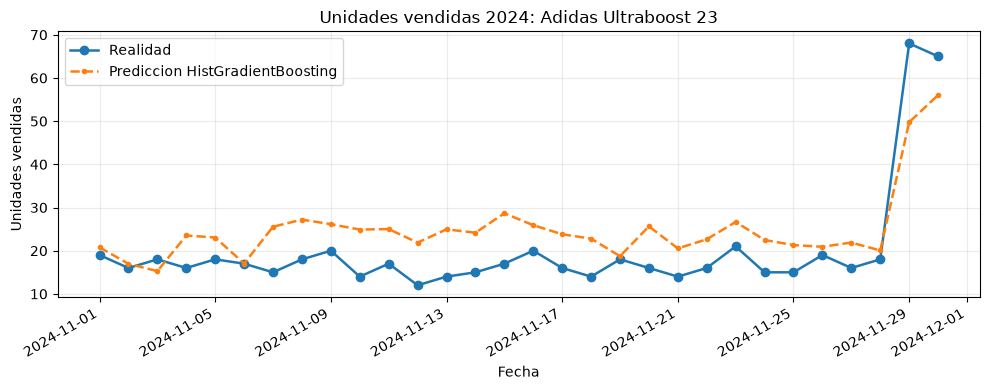

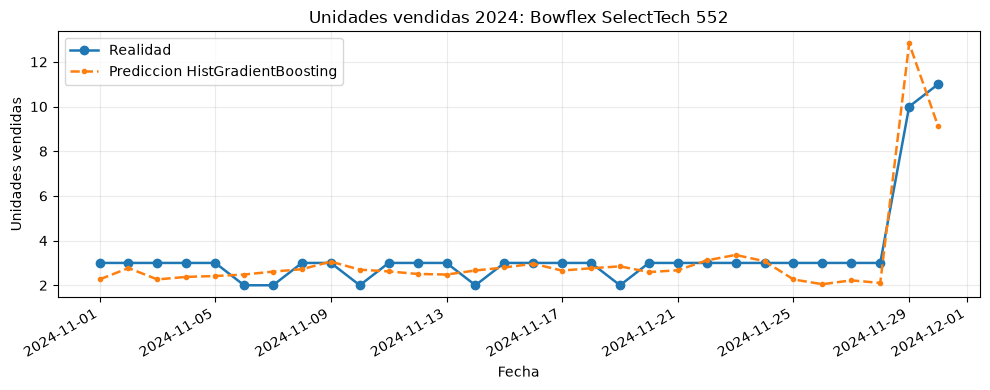

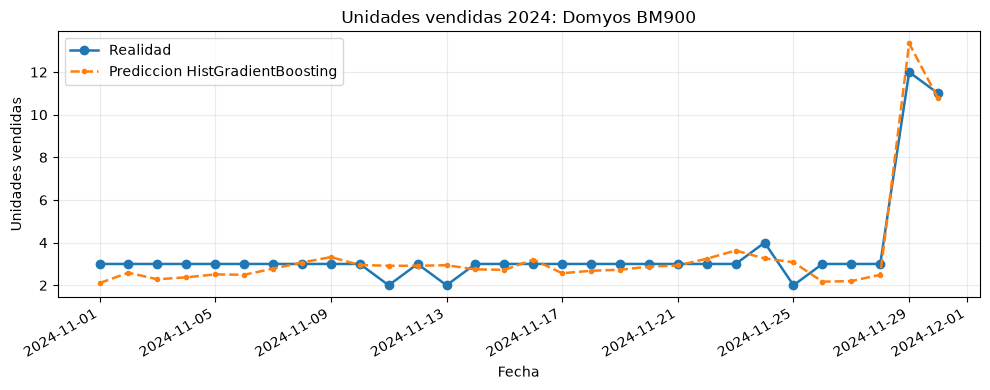

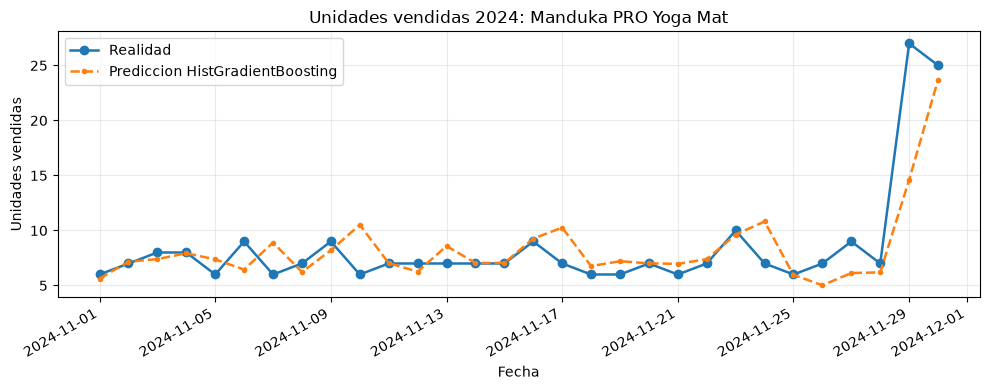

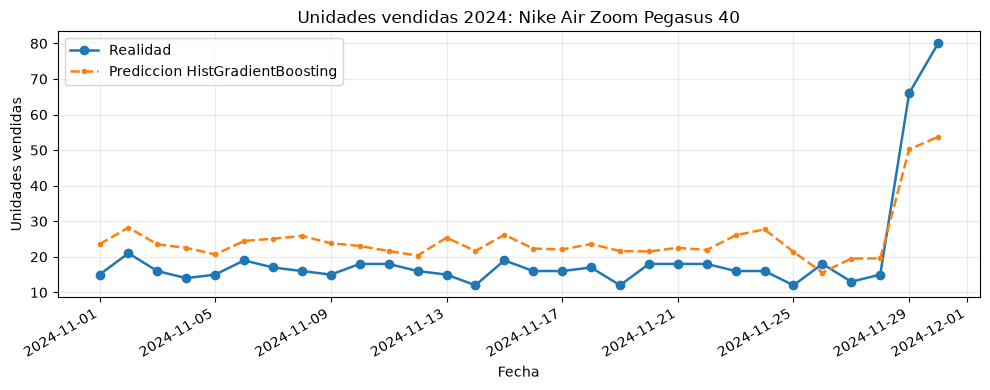

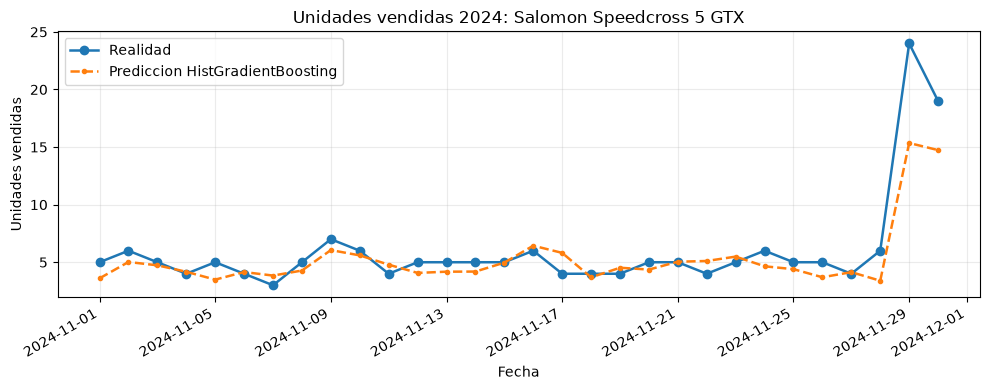

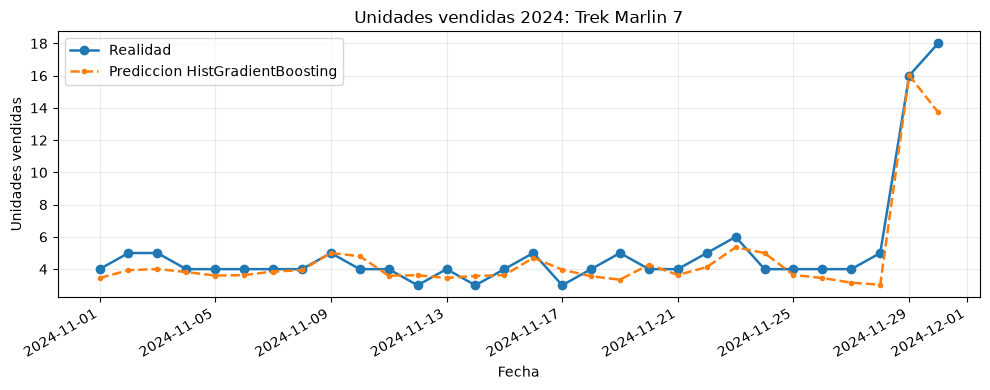

In [64]:
# Filtra los registros de validacion 2024 correspondientes a productos estrella.
mascara_productos_estrella = validation_df["es_estrella"]
predicciones_productos_estrella = validation_df.loc[
    mascara_productos_estrella,
    ["fecha", "producto_id", "nombre", "unidades_vendidas"],
].copy()

# Genera una prediccion para cada registro filtrado con las mismas predictoras del modelo.
predicciones_productos_estrella["prediccion_unidades"] = (
    modelo_hist_gradient.predict(
        validation_df.loc[mascara_productos_estrella, columnas_predictoras]
    )
)

# Obtiene el catalogo de productos estrella presentes en validacion.
productos_estrella_2024 = (
    predicciones_productos_estrella[["producto_id", "nombre"]]
    .drop_duplicates()
    .sort_values("nombre")
    .reset_index(drop=True)
)
print(
    "Productos estrella en validacion:",
    productos_estrella_2024["producto_id"].nunique(),
)
print(
    "Registros con prediccion:",
    len(predicciones_productos_estrella),
)
print(productos_estrella_2024.to_string(index=False))

# Traza realidad y prediccion en un grafico independiente por producto.
for producto_estrella in productos_estrella_2024.itertuples(index=False):
    datos_producto_estrella = (
        predicciones_productos_estrella.loc[
            predicciones_productos_estrella["producto_id"].eq(
                producto_estrella.producto_id
            )
        ]
        .sort_values("fecha")
    )
    figura_producto, ejes_producto = plt.subplots(figsize=(10, 4))
    ejes_producto.plot(
        datos_producto_estrella["fecha"],
        datos_producto_estrella["unidades_vendidas"],
        marker="o",
        linewidth=1.8,
        label="Realidad",
    )
    ejes_producto.plot(
        datos_producto_estrella["fecha"],
        datos_producto_estrella["prediccion_unidades"],
        marker=".",
        linestyle="--",
        linewidth=1.8,
        label="Prediccion HistGradientBoosting",
    )
    ejes_producto.set_title(
        f"Unidades vendidas 2024: {producto_estrella.nombre}"
    )
    ejes_producto.set_xlabel("Fecha")
    ejes_producto.set_ylabel("Unidades vendidas")
    ejes_producto.legend()
    ejes_producto.grid(alpha=0.25)
    figura_producto.autofmt_xdate(rotation=30, ha="right")
    figura_producto.tight_layout()
    plt.show()

In [65]:
# Calcula el MAE por producto con las observaciones de validacion de 2024.
predicciones_productos_con_error = predicciones_productos_estrella.assign(
    error_absoluto=lambda datos: (
        datos["unidades_vendidas"] - datos["prediccion_unidades"]
    ).abs()
)
metricas_mae_productos_estrella = (
    predicciones_productos_con_error.groupby(
        ["producto_id", "nombre"],
        as_index=False,
    )
    .agg(
        MAE=("error_absoluto", "mean"),
        registros_validacion=("error_absoluto", "size"),
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

print("MAE por producto estrella en 2024:")
print(metricas_mae_productos_estrella.to_string(index=False, float_format="{:.3f}".format))

MAE por producto estrella en 2024:
producto_id                   nombre   MAE  registros_validacion
   PROD_010             Domyos BM900 0.488                    30
   PROD_009   Bowflex SelectTech 552 0.604                    30
   PROD_016            Trek Marlin 7 0.721                    30
   PROD_015 Salomon Speedcross 5 GTX 1.168                    30
   PROD_021     Manduka PRO Yoga Mat 1.568                    30
   PROD_002     Adidas Ultraboost 23 6.904                    30
   PROD_001 Nike Air Zoom Pegasus 40 7.908                    30


In [66]:
# Prepara el conjunto completo para reentrenar el modelo final con 2021-2024.
df_historico_completo = df_modelado_encoded.sort_values(
    ["anio", "fecha", "producto_id"]
).copy()
x_full = df_historico_completo[columnas_predictoras]
y_full = df_historico_completo[variable_objetivo]

# Reutiliza exactamente los hiperparametros del modelo evaluado.
modelo_hist_gradient_final = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_leaf_nodes=15,
    max_depth=4,
    min_samples_leaf=30,
    l2_regularization=10.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)
modelo_hist_gradient_final.fit(x_full, y_full)

print("Modelo final entrenado con todo el historico disponible.")
print(f"Anios incluidos: {sorted(df_historico_completo['anio'].unique().tolist())}")
print(f"Filas de entrenamiento final: {len(x_full):,}")
print(f"Numero de predictoras: {x_full.shape[1]}")
print(f"Iteraciones efectivas: {modelo_hist_gradient_final.n_iter_}")

Modelo final entrenado con todo el historico disponible.
Anios incluidos: [2021, 2022, 2023, 2024]
Filas de entrenamiento final: 2,880
Numero de predictoras: 77
Iteraciones efectivas: 106


Permutation importance calculada en datos de entrenamiento (in-sample).
Las mayores importancias indican mas aumento de MAE al permutar la variable.
Primeras variables por importancia:
               variable  importancia_media  desviacion_std
unidades_vendidas_lag_1             1.1182          0.0197
   descuento_porcentaje             1.0004          0.0250
     media_movil_7_dias             0.5629          0.0138
unidades_vendidas_lag_7             0.5428          0.0181
        es_black_friday             0.1004          0.0048
         dia_semana_sin             0.0630          0.0045
     precio_competencia             0.0552          0.0084
unidades_vendidas_lag_6             0.0467          0.0028
             dia_semana             0.0320          0.0037
           ratio_precio             0.0207          0.0017


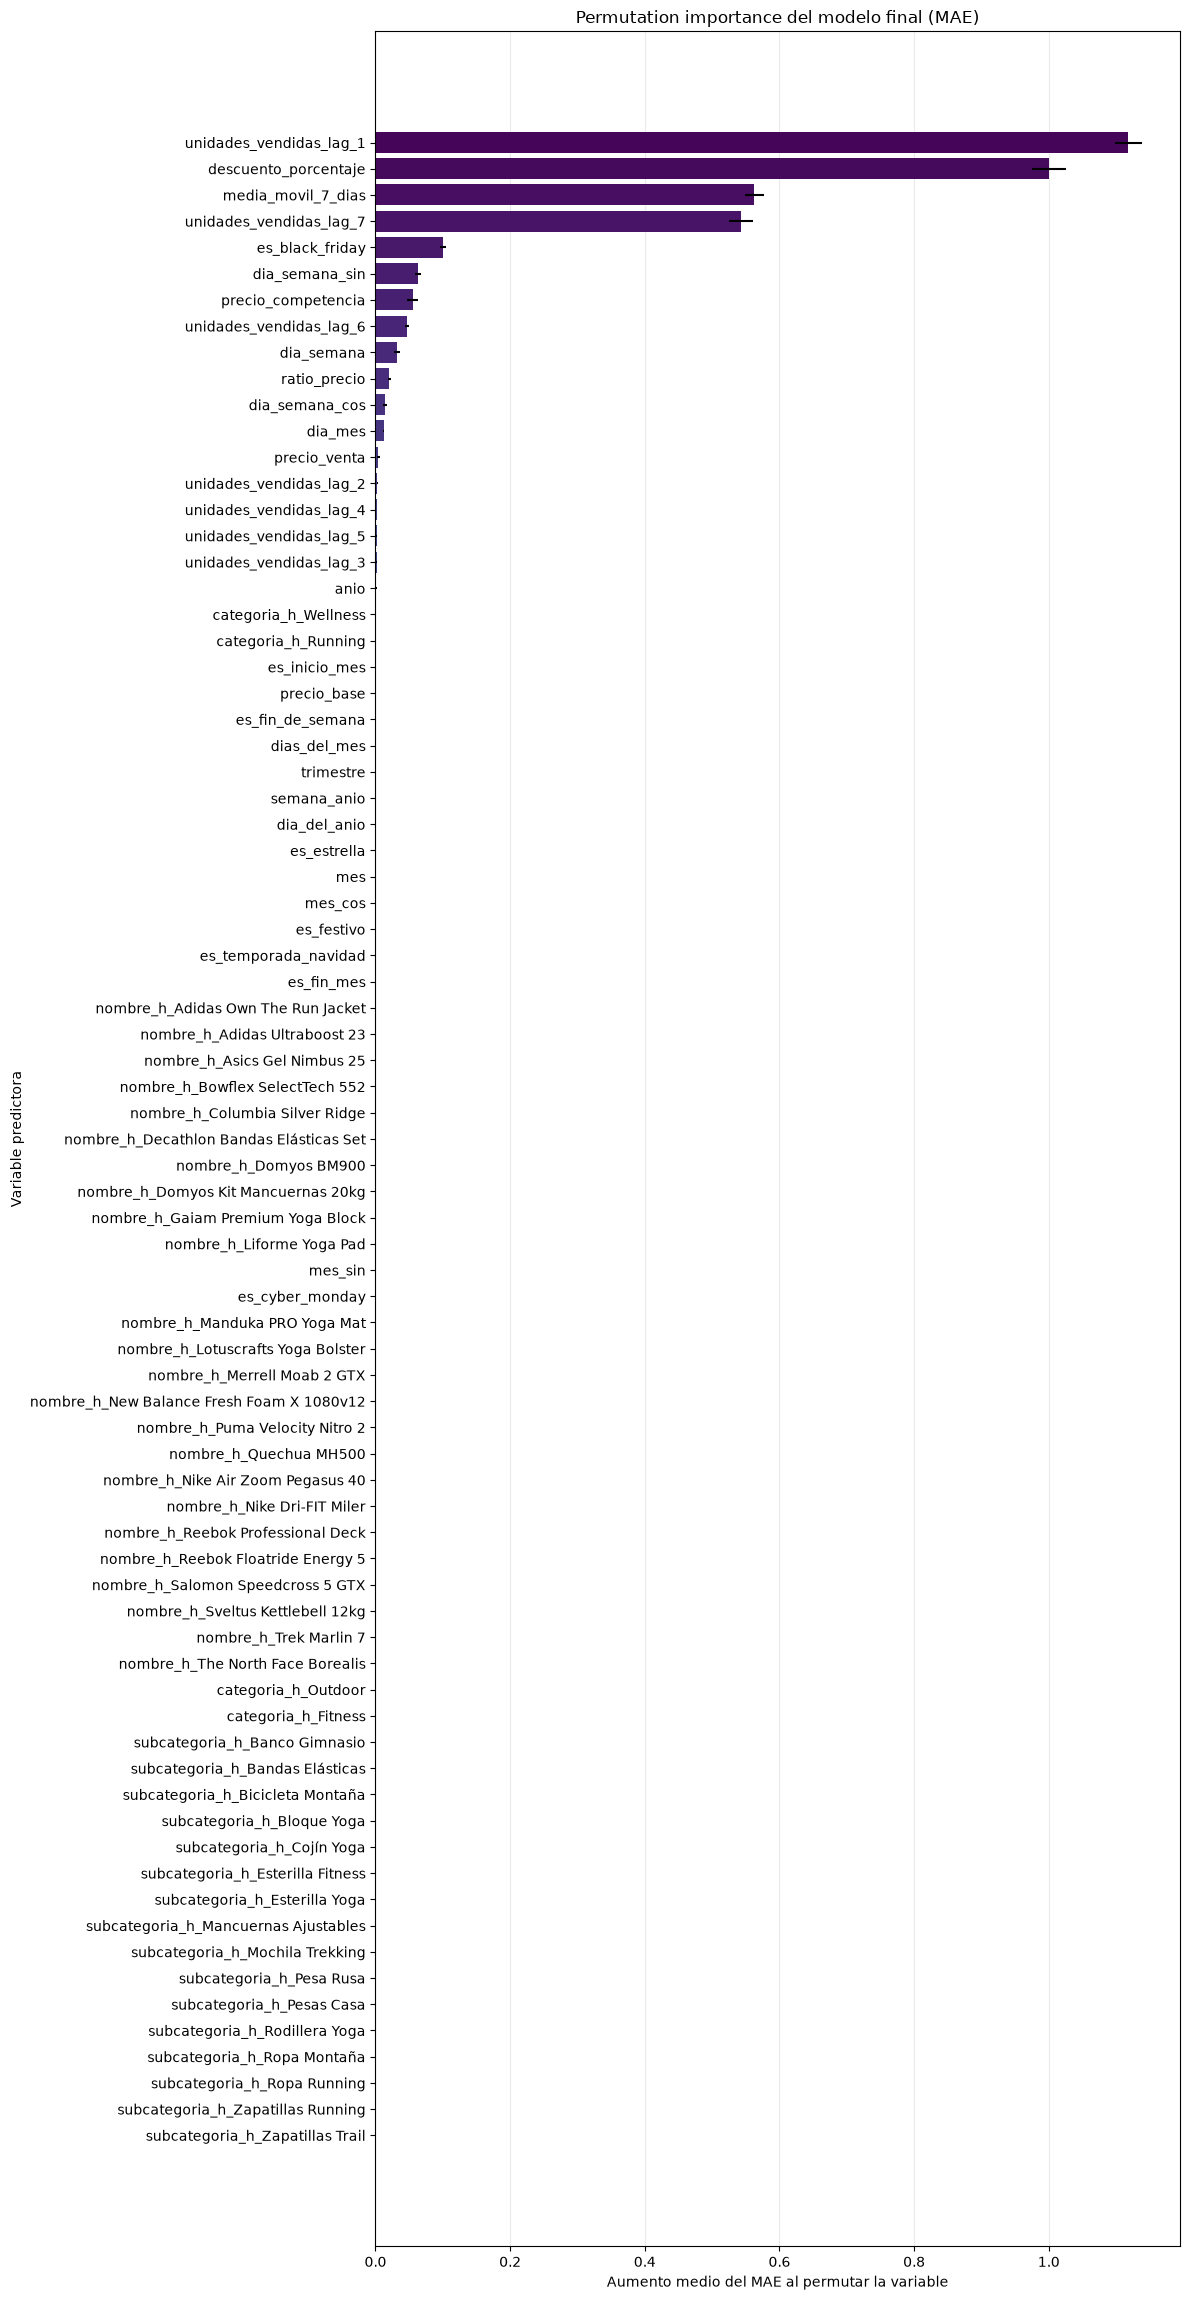

Modelo final guardado en: ../models/modelo_final.joblib


In [67]:
# Calcula permutation importance sobre el historico completo de entrenamiento.
from sklearn.inspection import permutation_importance
import joblib

resultado_permutation_importance = permutation_importance(
    modelo_hist_gradient_final,
    x_full,
    y_full,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

# Ordena las variables por incremento medio del MAE al permutarlas.
importancia_variables_final = (
    pd.DataFrame(
        {
            "variable": x_full.columns,
            "importancia_media": resultado_permutation_importance.importances_mean,
            "desviacion_std": resultado_permutation_importance.importances_std,
        }
    )
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

print("Permutation importance calculada en datos de entrenamiento (in-sample).")
print("Las mayores importancias indican mas aumento de MAE al permutar la variable.")
print("Primeras variables por importancia:")
print(importancia_variables_final.head(10).to_string(index=False, float_format="{:.4f}".format))

# Grafica todas las variables en orden descendente de importancia.
altura_grafico_importancia = max(8, len(importancia_variables_final) * 0.3)
figura_importancia, ejes_importancia = plt.subplots(
    figsize=(12, altura_grafico_importancia)
)
ejes_importancia.barh(
    importancia_variables_final["variable"],
    importancia_variables_final["importancia_media"],
    xerr=importancia_variables_final["desviacion_std"],
    color=sns.color_palette("viridis", n_colors=len(importancia_variables_final)),
)
ejes_importancia.invert_yaxis()
ejes_importancia.set_title("Permutation importance del modelo final (MAE)")
ejes_importancia.set_xlabel("Aumento medio del MAE al permutar la variable")
ejes_importancia.set_ylabel("Variable predictora")
ejes_importancia.grid(axis="x", alpha=0.25)
ejes_importancia.set_axisbelow(True)
figura_importancia.tight_layout()
plt.show()

# Guarda el estimador final para reutilizarlo en predicciones.
ruta_modelo_final = "../models/modelo_final.joblib"
joblib.dump(modelo_hist_gradient_final, ruta_modelo_final)
print(f"Modelo final guardado en: {ruta_modelo_final}")